In [1]:
import matplotlib.pyplot as plt
import torch

Available materials:
['Au', 'Ag', 'Cu', 'Al', 'SiO2', 'Si3N4', 'cSi', 'TiO2', 'aSi']


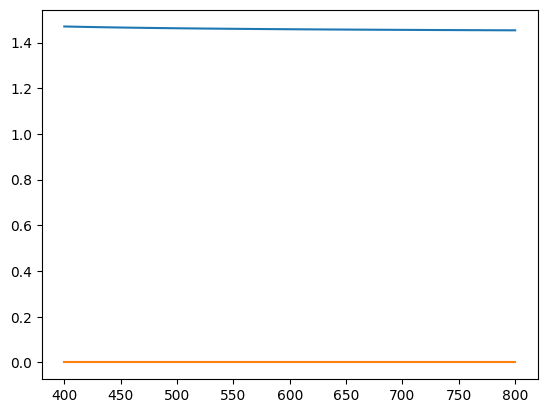

In [2]:
# Check dispersion
from dispertorch import material, list_materials
print(f"Available materials:")
print([mat for mat in list_materials().keys()])

au = material('SiO2')
wl = torch.linspace(400, 800, 41)

plt.plot(wl, au.n(wl))
plt.plot(wl, au.k(wl))


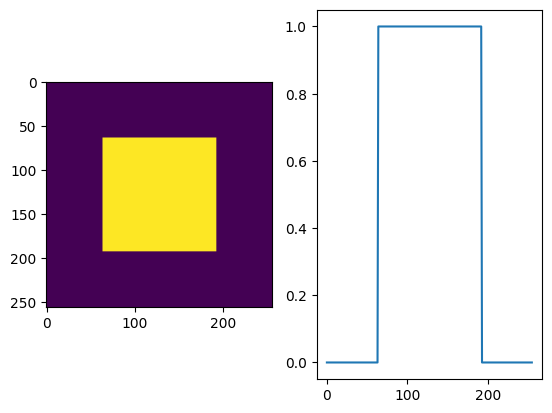

In [3]:
# chech shapes
from metashapes import Lattice, UnitCell
from metashapes.shape import Rectangle

Lx = 1.0
Ly = 1.0
lattice = Lattice.rectangular(Lx, Ly)

center = (0.5, 0.5)
size = (0.5, 0.5)
angle = 0
rect = Rectangle(center, size, angle=angle)

rect_cell = UnitCell(lattice, rect)
Nx = 256
Ny = 256

mask = rect_cell.mask(Nx, Ny, soft=False, softness=0.04)

plt.subplot(121)
plt.imshow(mask)

plt.subplot(122)
plt.plot(mask[128,:])

In [2]:
# Test for shape_fn 

## Create a MetaShapes rectangle, lattice, call `shape_fn(lattice, nx, ny)` and check
## it returns a mask.

import matplotlib.pyplot as plt
from typing import Callable

import torch

from metashapes.shape import Rectangle
from src.metarcwa.model.utils import from_metashapes
from src.metarcwa.model.lattice import Lattice

# Lattice
Lx = 400
Ly = 400
lattice = Lattice.rectangular(Lx,Ly)

centre = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=True)
angle = torch.nn.Parameter(torch.tensor([10.0]), requires_grad=True)

rect = Rectangle(center=centre, size = size, angle=angle)

shape_fn_0 = from_metashapes(rect, soft = True, softness = 1.0)

mask_0 = shape_fn_0(lattice, 256, 256)
# sum = mask_0.sum()
# sum.backward()

# print(centre.grad)
# print(size.grad)
# print(angle.grad)

#plt.imshow(mask_0)


{'Au': ['rakic-ld'], 'Ag': ['rakic-ld'], 'Cu': ['rakic-ld'], 'Al': ['rakic-ld'], 'SiO2': ['malitson'], 'Si3N4': ['luke'], 'cSi': ['salzberg'], 'TiO2': ['devore-o'], 'aSi': ['jellison-modine']}
None
torch.Size([50])
torch.complex64


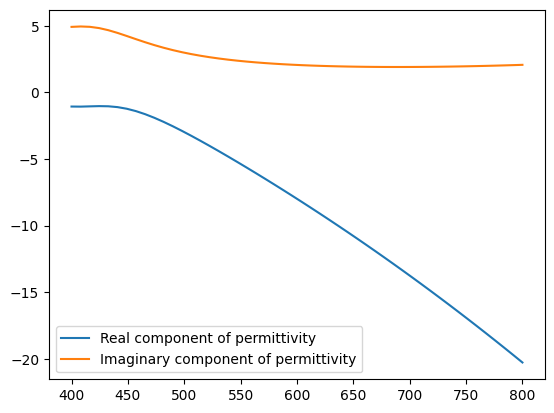

In [3]:
# Test for eps_fn

## Test epsilon with a material like gold:
## Create gold from DisperTorch, wrap it with `from_dispertorch`
## call `eps_fn(wl)` and inspect output


from dispertorch import material, list_materials
from src.metarcwa.model.utils import from_dispertorch

print(list_materials())


au = material("Au")
wl = torch.linspace(400,800,50)

au.terms[0].eps_re = torch.nn.Parameter(torch.tensor([1.0]), requires_grad=True)

eps_fn_0 = from_dispertorch(au)
eps_0 = eps_fn_0(wl)
# sum = eps_0.abs().sum()
# sum.backward()

print(au.terms[0].eps_re.grad)

print(eps_0.shape)
print(eps_0.dtype)

plt.plot(wl, eps_0.detach().real, label = "Real component of permittivity")
plt.plot(wl, eps_0.detach().imag, label = "Imaginary component of permittivity")
plt.legend()
plt.show()

In [4]:
# Test layer
# Gold rectangle in Air with a thickness of 100

from src.metarcwa.model.layer import Layer
from src.metarcwa.model.stack import Stack

def air_fn(wl):
    return (1 + 0j)*torch.ones_like(wl)

layer_0 = Layer(
    eps_solid_fn = eps_fn_0,
    thickness = torch.tensor(100.0),
    eps_void_fn = air_fn,
    shape_fn = shape_fn_0
)

print(layer_0)
print(layer_0.thickness)


Layer(
  (eps_solid_fn): CallableModule(
    (_deps): ModuleList(
      (0): Composite(
        (terms): ModuleList(
          (0): ConstantEps()
          (1): Drude()
          (2-6): 5 x Lorentz()
        )
      )
    )
  )
  (shape_fn): CallableModule(
    (_deps): ModuleList(
      (0): Rectangle()
    )
  )
)
tensor(100.)


In [5]:
# Create Stack
# Simple stack for testing where air in the incidence and transmission medium
# with layer_0 in between

stack = Stack(
    incidence = air_fn,
    layers = [layer_0],
    transmission = air_fn,
    lattice=lattice,
    grid_shape = (256,256)
)

print(stack)
print(stack.layers)

spec = stack.spec(wl)

print(spec.layer_eps.shape)
print(spec.layer_eps.dtype)
print(spec.layer_thickness)
print(spec.eps_incidence.shape)
print(spec.eps_transmission.shape)

Stack(
  (layers): ModuleList(
    (0): Layer(
      (eps_solid_fn): CallableModule(
        (_deps): ModuleList(
          (0): Composite(
            (terms): ModuleList(
              (0): ConstantEps()
              (1): Drude()
              (2-6): 5 x Lorentz()
            )
          )
        )
      )
      (shape_fn): CallableModule(
        (_deps): ModuleList(
          (0): Rectangle()
        )
      )
    )
  )
  (lattice): Lattice()
)
ModuleList(
  (0): Layer(
    (eps_solid_fn): CallableModule(
      (_deps): ModuleList(
        (0): Composite(
          (terms): ModuleList(
            (0): ConstantEps()
            (1): Drude()
            (2-6): 5 x Lorentz()
          )
        )
      )
    )
    (shape_fn): CallableModule(
      (_deps): ModuleList(
        (0): Rectangle()
      )
    )
  )
)
torch.Size([1, 50, 256, 256])
torch.complex64
tensor([100.])
torch.Size([50])
torch.Size([50])


In [6]:
from src.metarcwa.model.source import PlaneWave
wl = torch.linspace(400,800,50)
theta = torch.linspace(0, 45, 46)
phi = torch.linspace(0, 10, 11)
s_amp = 1.0
p_amp = 0.0
source = PlaneWave(wl, s_amp, p_amp, theta, phi)

In [10]:
from src.metarcwa.model.base import Model
model = Model(stack, source)
model.to(dtype=torch.float32, device='cpu')

Model(
  (stack): Stack(
    (layers): ModuleList(
      (0): Layer(
        (eps_solid_fn): CallableModule(
          (_deps): ModuleList(
            (0): Composite(
              (terms): ModuleList(
                (0): ConstantEps()
                (1): Drude()
                (2-6): 5 x Lorentz()
              )
            )
          )
        )
        (shape_fn): CallableModule(
          (_deps): ModuleList(
            (0): Rectangle()
          )
        )
      )
    )
    (lattice): Lattice()
  )
  (source): PlaneWave()
)

In [11]:
for name, param in model.named_parameters():
    print(name, param)

stack.layers.0.eps_solid_fn._deps.0.terms.0.eps_re Parameter containing:
tensor([1.], requires_grad=True)
stack.layers.0.shape_fn._deps.0.center Parameter containing:
tensor([200., 200.], requires_grad=True)
stack.layers.0.shape_fn._deps.0.size Parameter containing:
tensor([200., 200.], requires_grad=True)
stack.layers.0.shape_fn._deps.0.angle Parameter containing:
tensor([10.], requires_grad=True)


In [12]:
for name, tensor in model.spec().named_tensors():
    print(name, tensor.shape, tensor.dtype, tensor.device)

stack.layer_eps torch.Size([1, 50, 256, 256]) torch.complex64 cpu
stack.layer_thickness torch.Size([1]) torch.float32 cpu
stack.eps_incidence torch.Size([50]) torch.complex64 cpu
stack.eps_transmission torch.Size([50]) torch.complex64 cpu
stack.a1 torch.Size([2]) torch.float32 cpu
stack.a2 torch.Size([2]) torch.float32 cpu
source.wavelength torch.Size([50, 1, 1]) torch.float32 cpu
source.kx0 torch.Size([50, 46, 11]) torch.complex64 cpu
source.ky0 torch.Size([50, 46, 11]) torch.complex64 cpu
source.s torch.Size([]) torch.complex64 cpu
source.p torch.Size([]) torch.complex64 cpu
